First Initial Script for understanding the data drill down in details and get the insights

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the dataset : 
df  = pd.read_csv("../data/supply_chain_dataset.csv")

In [3]:
df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


Lets check some basic analytics like info , description , shape size ,  describe . etc

In [4]:
df.tail()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
91245,2024-12-26,SKU_50,WH_5,SUP_10,South,17,352,7,283,0,6.65,9.6,0,0,19.82
91246,2024-12-27,SKU_50,WH_5,SUP_10,South,21,331,7,283,0,6.65,9.6,0,0,27.96
91247,2024-12-28,SKU_50,WH_5,SUP_10,East,17,314,7,283,0,6.65,9.6,0,0,22.13
91248,2024-12-29,SKU_50,WH_5,SUP_10,South,24,290,7,283,0,6.65,9.6,1,0,24.11
91249,2024-12-30,SKU_50,WH_5,SUP_10,West,15,275,7,283,0,6.65,9.6,1,0,20.19


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     91250 non-null  object 
 1   SKU_ID                   91250 non-null  object 
 2   Warehouse_ID             91250 non-null  object 
 3   Supplier_ID              91250 non-null  object 
 4   Region                   91250 non-null  object 
 5   Units_Sold               91250 non-null  int64  
 6   Inventory_Level          91250 non-null  int64  
 7   Supplier_Lead_Time_Days  91250 non-null  int64  
 8   Reorder_Point            91250 non-null  int64  
 9   Order_Quantity           91250 non-null  int64  
 10  Unit_Cost                91250 non-null  float64
 11  Unit_Price               91250 non-null  float64
 12  Promotion_Flag           91250 non-null  int64  
 13  Stockout_Flag            91250 non-null  int64  
 14  Demand_Forecast       

In [6]:
df.describe()

,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.0,91250.000000
mean,20.054564,471.522312,7.984000,300.068000,19.272493,12.203320,18.261800,0.101589,0.0,20.082033
std,9.068602,133.488002,3.907929,54.879945,82.340831,4.574982,7.121136,0.302109,0.0,9.503955
min,0.000000,168.000000,2.000000,201.000000,0.000000,5.020000,6.950000,0.000000,0.0,0.000000
25%,13.000000,370.000000,4.000000,252.000000,0.000000,8.180000,12.000000,0.000000,0.0,12.950000
50%,20.000000,461.000000,8.000000,300.000000,0.000000,11.990000,18.180000,0.000000,0.0,19.950000
75%,27.000000,564.000000,11.000000,346.000000,0.000000,16.320000,23.390000,0.000000,0.0,26.930000
max,59.000000,990.000000,14.000000,398.000000,499.000000,19.760000,35.100000,1.000000,0.0,61.420000


In [7]:
df.shape

(91250, 15)

In [8]:
# Lets check for the null and Duplicate values in the dataser  : 

df.isnull().sum()

Date                       0
SKU_ID                     0
Warehouse_ID               0
Supplier_ID                0
Region                     0
Units_Sold                 0
Inventory_Level            0
Supplier_Lead_Time_Days    0
Reorder_Point              0
Order_Quantity             0
Unit_Cost                  0
Unit_Price                 0
Promotion_Flag             0
Stockout_Flag              0
Demand_Forecast            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

As we can see there is No null values Nor these are any duplicate values in the datadrame. 


### Lets start with the Univariate , Bivariate and Multivariate Analysis then

# Univariate Analysis

These are the columns in which I will do the univaraite analysis  : 
<br>                         
 4   Region                 
 5   Units_Sold              
 6   Inventory_Level          
 7   Supplier_Lead_Time_Days  
 8   Reorder_Point            
 9   Order_Quantity          
 10  Unit_Cost               
 11  Unit_Price               
 13  Stockout_Flag           
 14  Demand_Forecast

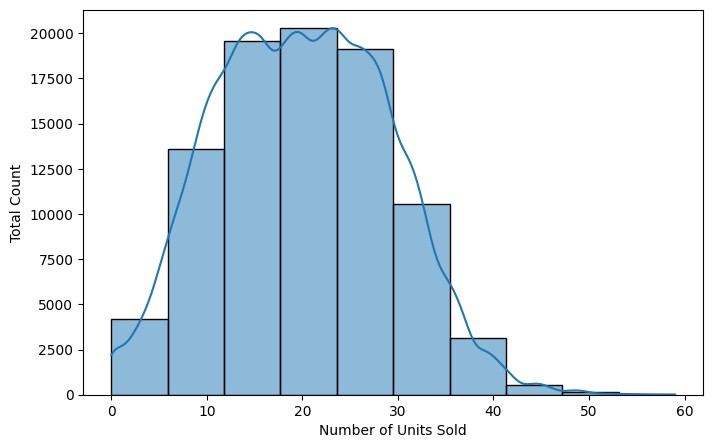

In [10]:
# Lets see the distribution of the units sold : 

plt.figure(figsize= (8 , 5))
sns.histplot(df['Units_Sold'] , kde=10 , bins=10)
plt.xlabel("Number of Units Sold")
plt.ylabel("Total Count")
plt.show()

As we can see that the Graph is the Positive Skew. Most of the Distributions in the Middle Range - Most of the items which are sold in teh range of 10 to max 30 and the high number of units are not sold in high count. 

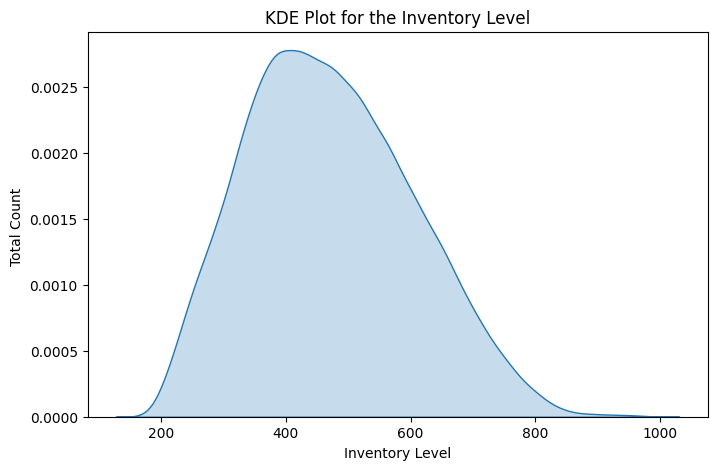

In [11]:
plt.figure(figsize  = (8 , 5))
plt.title("KDE Plot for the Inventory Level")
sns.kdeplot(df['Inventory_Level'], fill=True)
plt.xlabel("Inventory Level")
plt.ylabel("Total Count ")
plt.show()

As we can see from the inventory plot taht mos tof the inventory that is in stock is from the range of 200 - 800

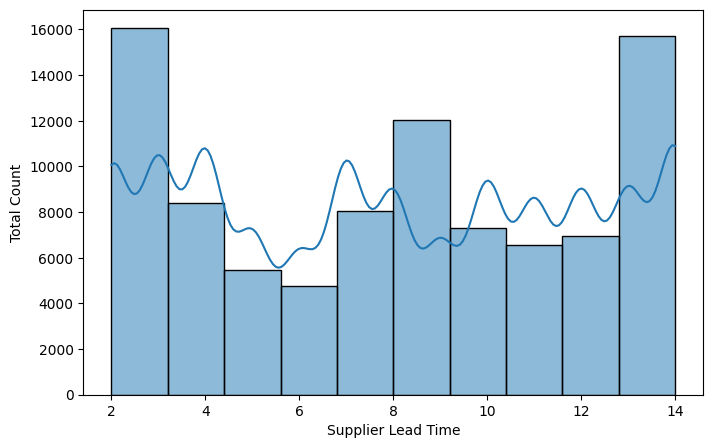

In [12]:
plt.figure(figsize= (8 , 5))
sns.histplot(df['Supplier_Lead_Time_Days'] , kde=10 , bins=10)
plt.xlabel("Supplier Lead Time")
plt.ylabel("Total Count")
plt.show()

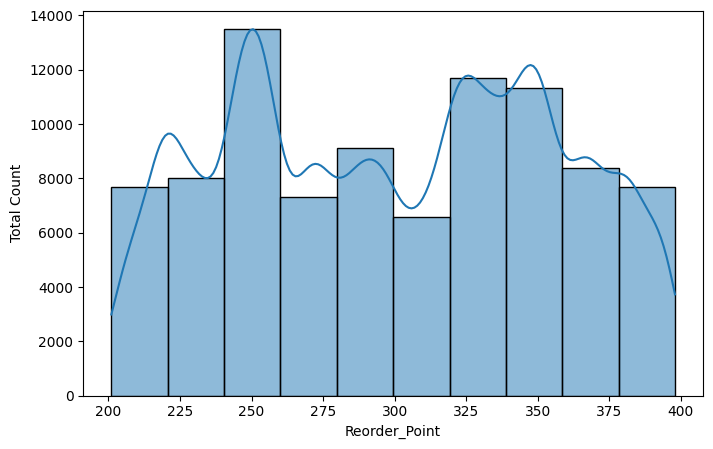

In [13]:
plt.figure(figsize= (8 , 5))
sns.histplot(df['Reorder_Point'] , kde=10 , bins=10)
plt.xlabel("Reorder_Point")
plt.ylabel("Total Count")
plt.show()

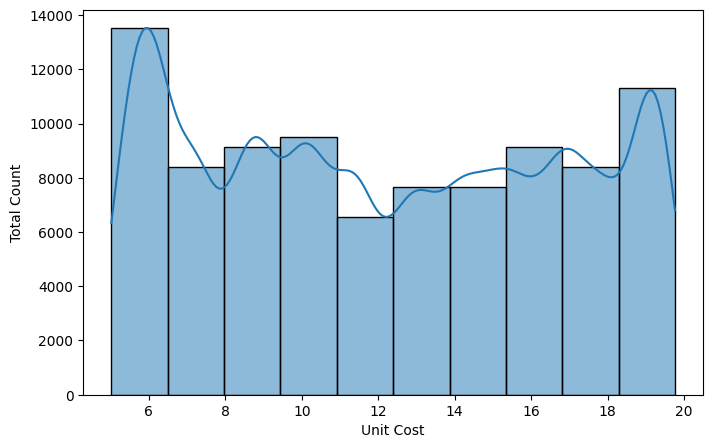

In [14]:
plt.figure(figsize= (8 , 5))
sns.histplot(df['Unit_Cost'] , kde=10 , bins=10)
plt.xlabel("Unit Cost")
plt.ylabel("Total Count")
plt.show()

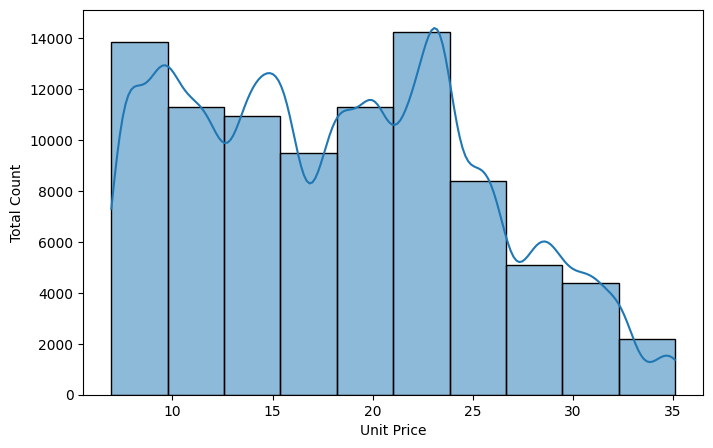

In [15]:
plt.figure(figsize= (8 , 5))
sns.histplot(df['Unit_Price'] , kde=10 , bins=10)
plt.xlabel("Unit Price")
plt.ylabel("Total Count")
plt.show()

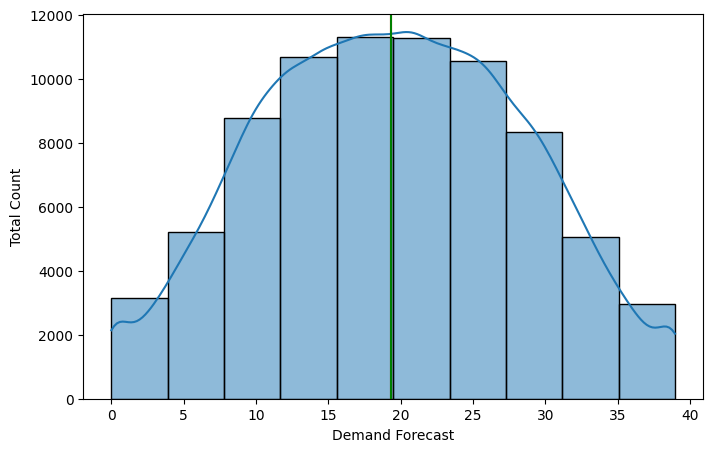

In [38]:
plt.figure(figsize= (8 , 5))
sns.histplot(df['Demand_Forecast'] , kde=10 , bins=10)
plt.xlabel("Demand Forecast")
plt.axvline(df.Demand_Forecast.mean() , label = "mean" , color  = "red")
plt.axvline(df.Demand_Forecast.median() , label  = "median" , color = "green")
plt.ylabel("Total Count")
plt.show()

Lets chekc for the outliers in the dataset: 

In [17]:
column_names  = df.columns
print(column_names)

Index(['Date', 'SKU_ID', 'Warehouse_ID', 'Supplier_ID', 'Region', 'Units_Sold',
       'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point',
       'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag',
       'Stockout_Flag', 'Demand_Forecast'],
      dtype='object')


In [18]:
numerical_column  = df.select_dtypes(include=['number']).columns
print(numerical_column)

Index(['Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days',
       'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Promotion_Flag', 'Stockout_Flag', 'Demand_Forecast'],
      dtype='object')


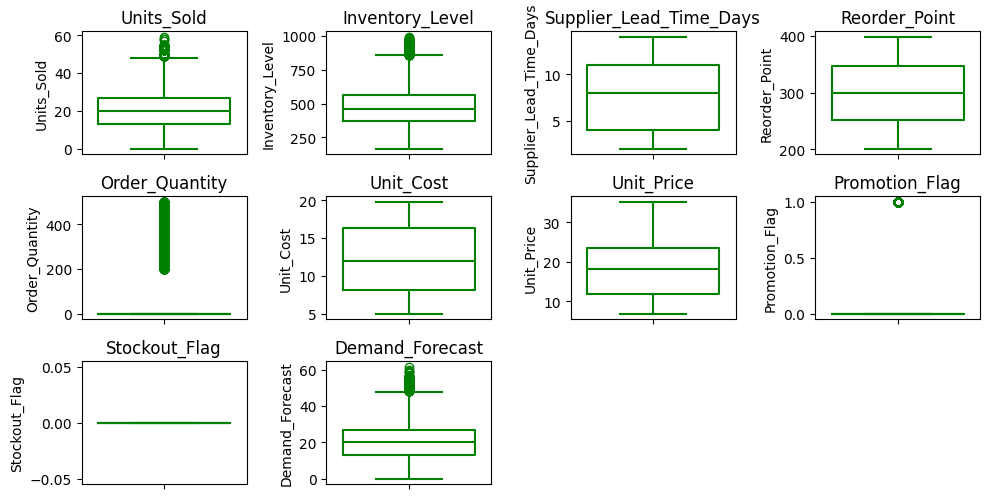

In [19]:
plt.figure(figsize=(10 , 10))

for i , columnname  in enumerate(numerical_column , 1):
    plt.subplot(6 , 4 , i) # The rows and column and the position
    sns.boxplot(df[columnname] , color="green"  ,linecolor="grey" , fill=False)
    plt.title(columnname)

plt.tight_layout()


Now we can see from the graphs that Some of the Columns have the outliers : Have the outliers and before doing More Depth EDA we need to remove the outliers and for that we will use the IQR 

In [20]:
num_df = df.select_dtypes(include='number')

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[~((num_df < lower_bound) | (num_df > upper_bound)).any(axis=1)]

In [21]:
df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70
5,2024-01-06,SKU_1,WH_1,SUP_8,East,18,477,14,379,0,13.95,20.48,0,0,18.33


In [22]:
df.shape

(77287, 15)

0   Date                     91250 non-null  object 
 1   SKU_ID                   91250 non-null  object 
 2   Warehouse_ID             91250 non-null  object 
 3   Supplier_ID              91250 non-null  object 
 4   Region                   91250 non-null  object 
 5   Units_Sold               91250 non-null  int64  
 6   Inventory_Level          91250 non-null  int64  
 7   Supplier_Lead_Time_Days  91250 non-null  int64  
 8   Reorder_Point            91250 non-null  int64  
 9   Order_Quantity           91250 non-null  int64  
 10  Unit_Cost                91250 non-null  float64
 11  Unit_Price               91250 non-null  float64
 12  Promotion_Flag           91250 non-null  int64  
 13  Stockout_Flag            91250 non-null  int64  
 14  Demand_Forecast          91250 non-null  float64

In [43]:
# Check the count of categories for each category type and make sure how many coategories for each category type exists  : 


print(f'Count for SKU ID is {df.SKU_ID.nunique()}')
print(f'Count for Warehouse ID is {df.Warehouse_ID.nunique()}')
print(f'Count for Supplier ID is {df.Supplier_ID.nunique()}')
print(f'Count of Region is {df.Region.nunique()}')

Count for SKU ID is 50
Count for Warehouse ID is 5
Count for Supplier ID is 10
Count of Region is 4


Now we we can see that there are sku id is 50 and warehouse id is 5 and supplier id is 10 and region is 4.
<br>
which means there are 50 items and warehouse are 5 while there are 10 supliers that are providing the materials and its being transported to 4 regions. 

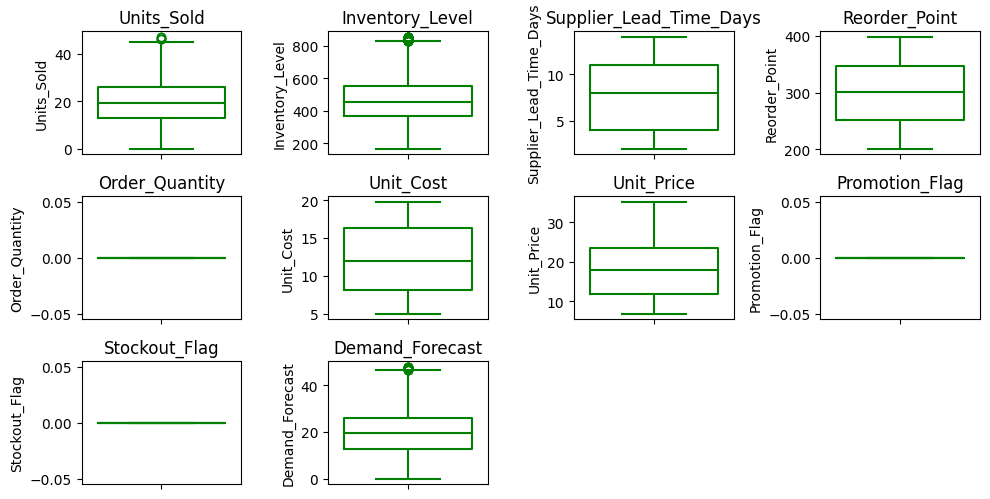

In [23]:
# Lets check once more about the outliers again and confirm that there are no outliers in the dataset then  : 

plt.figure(figsize=(10 , 10))

for i , columnname  in enumerate(numerical_column , 1):
    plt.subplot(6 , 4 , i) # The rows and column and the position
    sns.boxplot(df[columnname] , color="green"  ,linecolor="grey" , fill=False)
    plt.title(columnname)

plt.tight_layout()



We can see clearly the IQR is not working for our dataset and we need to use some more aggressive methods. 
Next method is capping so that the outliers values are capped to the lower values to the first percentile and outer values to the last percentile. 
Then we will see the result

In [26]:
numerical_column  = df.select_dtypes(include='number').copy()
lower_bound  = numerical_column.quantile(0.01)
upper_bound  = numerical_column.quantile(0.99)

numerical_column = numerical_column.clip(lower= lower_bound , upper=upper_bound , axis = 1)
df[numerical_column.columns] = numerical_column

In [27]:
df.shape

(77287, 15)

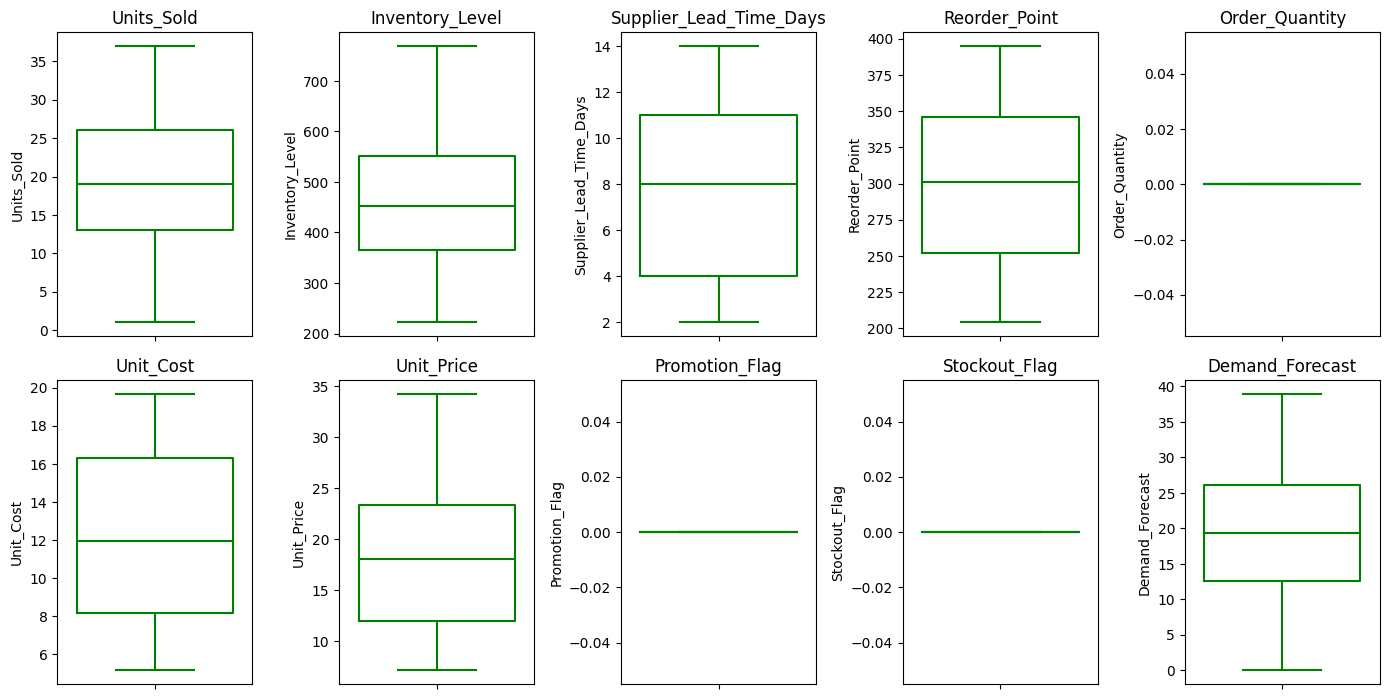

In [32]:
# Lets check for the outliers again : 

plt.figure(figsize=(14 , 14))

for i , columnname  in enumerate(numerical_column , 1):

    plt.subplot(4 , 5  , i) # The rows the column and the position 
    sns.boxplot(df[columnname] , color='green' , fill=False , linecolor='grey')
    plt.title(columnname)

plt.tight_layout()







Now there are no outliers in the dataset - lets check the spread of the dataset as well for tha twe will use the violin plot : 

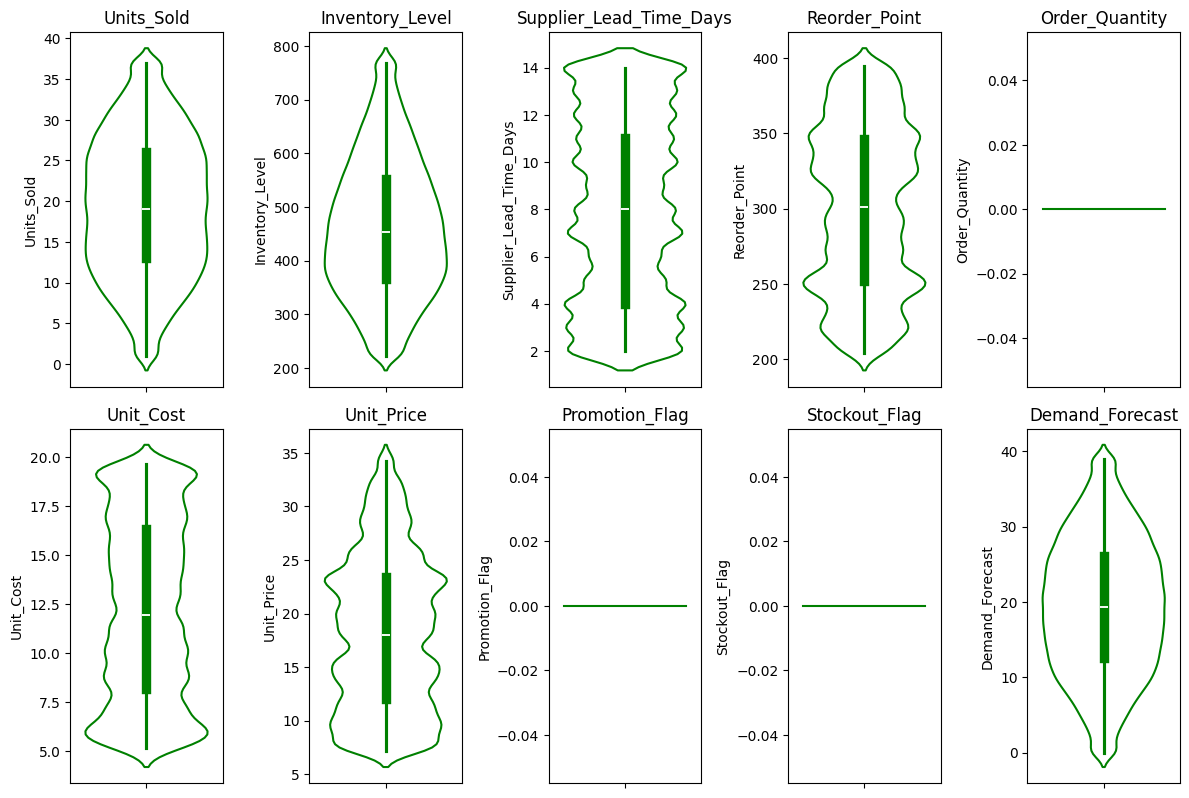

In [61]:
plt.figure(figsize=(12 , 12))

for i , columnname in enumerate(numerical_column , 1):
    plt.subplot( 3 , 5 , i)
    sns.violinplot(df[columnname] , color="green" , linecolor="grey" , fill=False)
    plt.title(columnname)

plt.tight_layout()
plt.show()





The violin plot shows an interesting insight  :  

Now we know that there is not outliers in the dataset and we can proceed for the bivariate analysis :

In [33]:
print(df.columns)

Index(['Date', 'SKU_ID', 'Warehouse_ID', 'Supplier_ID', 'Region', 'Units_Sold',
       'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point',
       'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag',
       'Stockout_Flag', 'Demand_Forecast'],
      dtype='object')


In [47]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 77287 entries, 0 to 91247
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     77287 non-null  object 
 1   SKU_ID                   77287 non-null  object 
 2   Warehouse_ID             77287 non-null  object 
 3   Supplier_ID              77287 non-null  object 
 4   Region                   77287 non-null  object 
 5   Units_Sold               77287 non-null  int64  
 6   Inventory_Level          77287 non-null  int64  
 7   Supplier_Lead_Time_Days  77287 non-null  int64  
 8   Reorder_Point            77287 non-null  int64  
 9   Order_Quantity           77287 non-null  int64  
 10  Unit_Cost                77287 non-null  float64
 11  Unit_Price               77287 non-null  float64
 12  Promotion_Flag           77287 non-null  int64  
 13  Stockout_Flag            77287 non-null  int64  
 14  Demand_Forecast          77

For the bivariate analysis i will use the following columns  : 
<br>

Units Sold vs inventory level
units cold vs demand forecast 
units sold vs unit price
inventory level vs reodrder point
supplier lead time days vs stockout flag
order quantity vs demand forecast

Region vs untis sold
region vs demand forecast
warehouse ID vs inventory level
supplier id vs lead time
stockout flag vs lead time 
promotion flag vs units sold

region vs stockout flag 
promotion flag vs stockout flag 



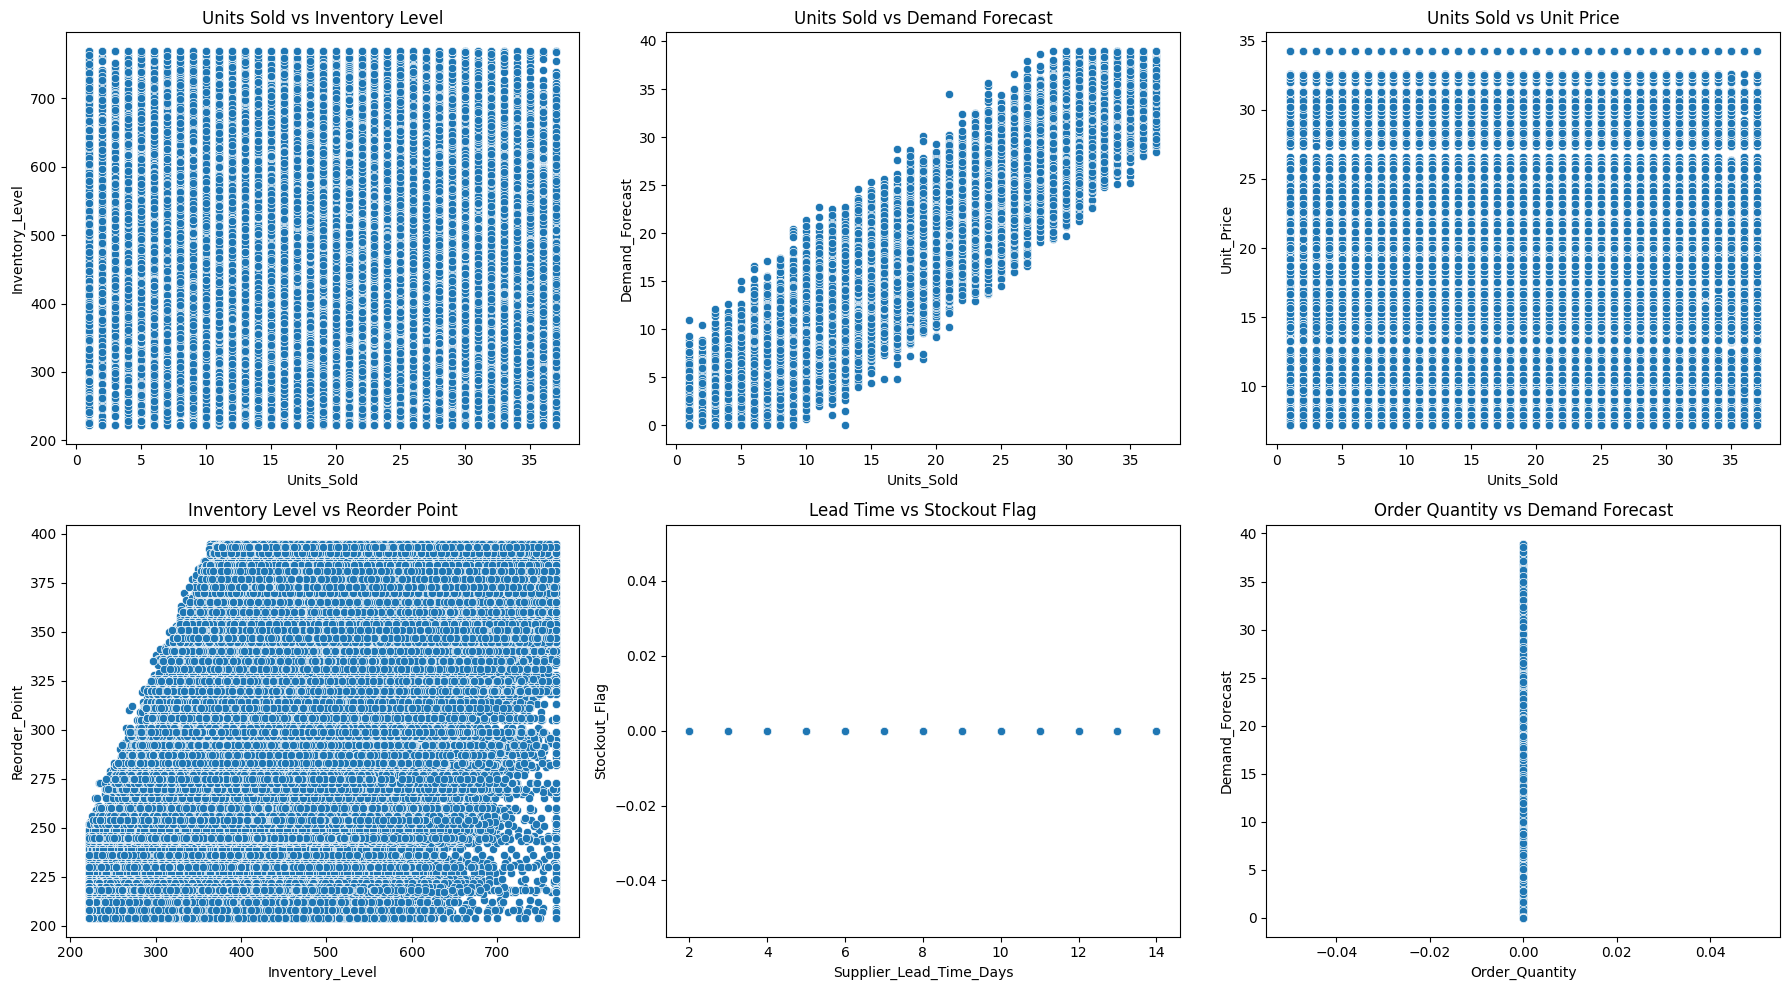

In [48]:
plt.figure(figsize=(18, 10))


plt.subplot(2, 3, 1)
sns.scatterplot(x=df['Units_Sold'], y=df['Inventory_Level'])
plt.title('Units Sold vs Inventory Level')


plt.subplot(2, 3, 2)
sns.scatterplot(x=df['Units_Sold'], y=df['Demand_Forecast'])
plt.title('Units Sold vs Demand Forecast')


plt.subplot(2, 3, 3)
sns.scatterplot(x=df['Units_Sold'], y=df['Unit_Price'])
plt.title('Units Sold vs Unit Price')

plt.subplot(2, 3, 4)
sns.scatterplot(x=df['Inventory_Level'], y=df['Reorder_Point'])
plt.title('Inventory Level vs Reorder Point')


plt.subplot(2, 3, 5)
sns.scatterplot(x=df['Supplier_Lead_Time_Days'], y=df['Stockout_Flag'])
plt.title('Lead Time vs Stockout Flag')


plt.subplot(2, 3, 6)
sns.scatterplot(x=df['Order_Quantity'], y=df['Demand_Forecast'])
plt.title('Order Quantity vs Demand Forecast')

plt.tight_layout()
plt.show()

From the above graph the observations are as follows  : 
<br> 

more the units sold are more is the demand forecast means units sold are directly proportional to the demand forecast. it shows the strong positive correlation. 
<br>
More the inventory level is the reorder point is also increased for exmaple things would only be reorderd when the inventory is less - reorder point depends on inventory policy


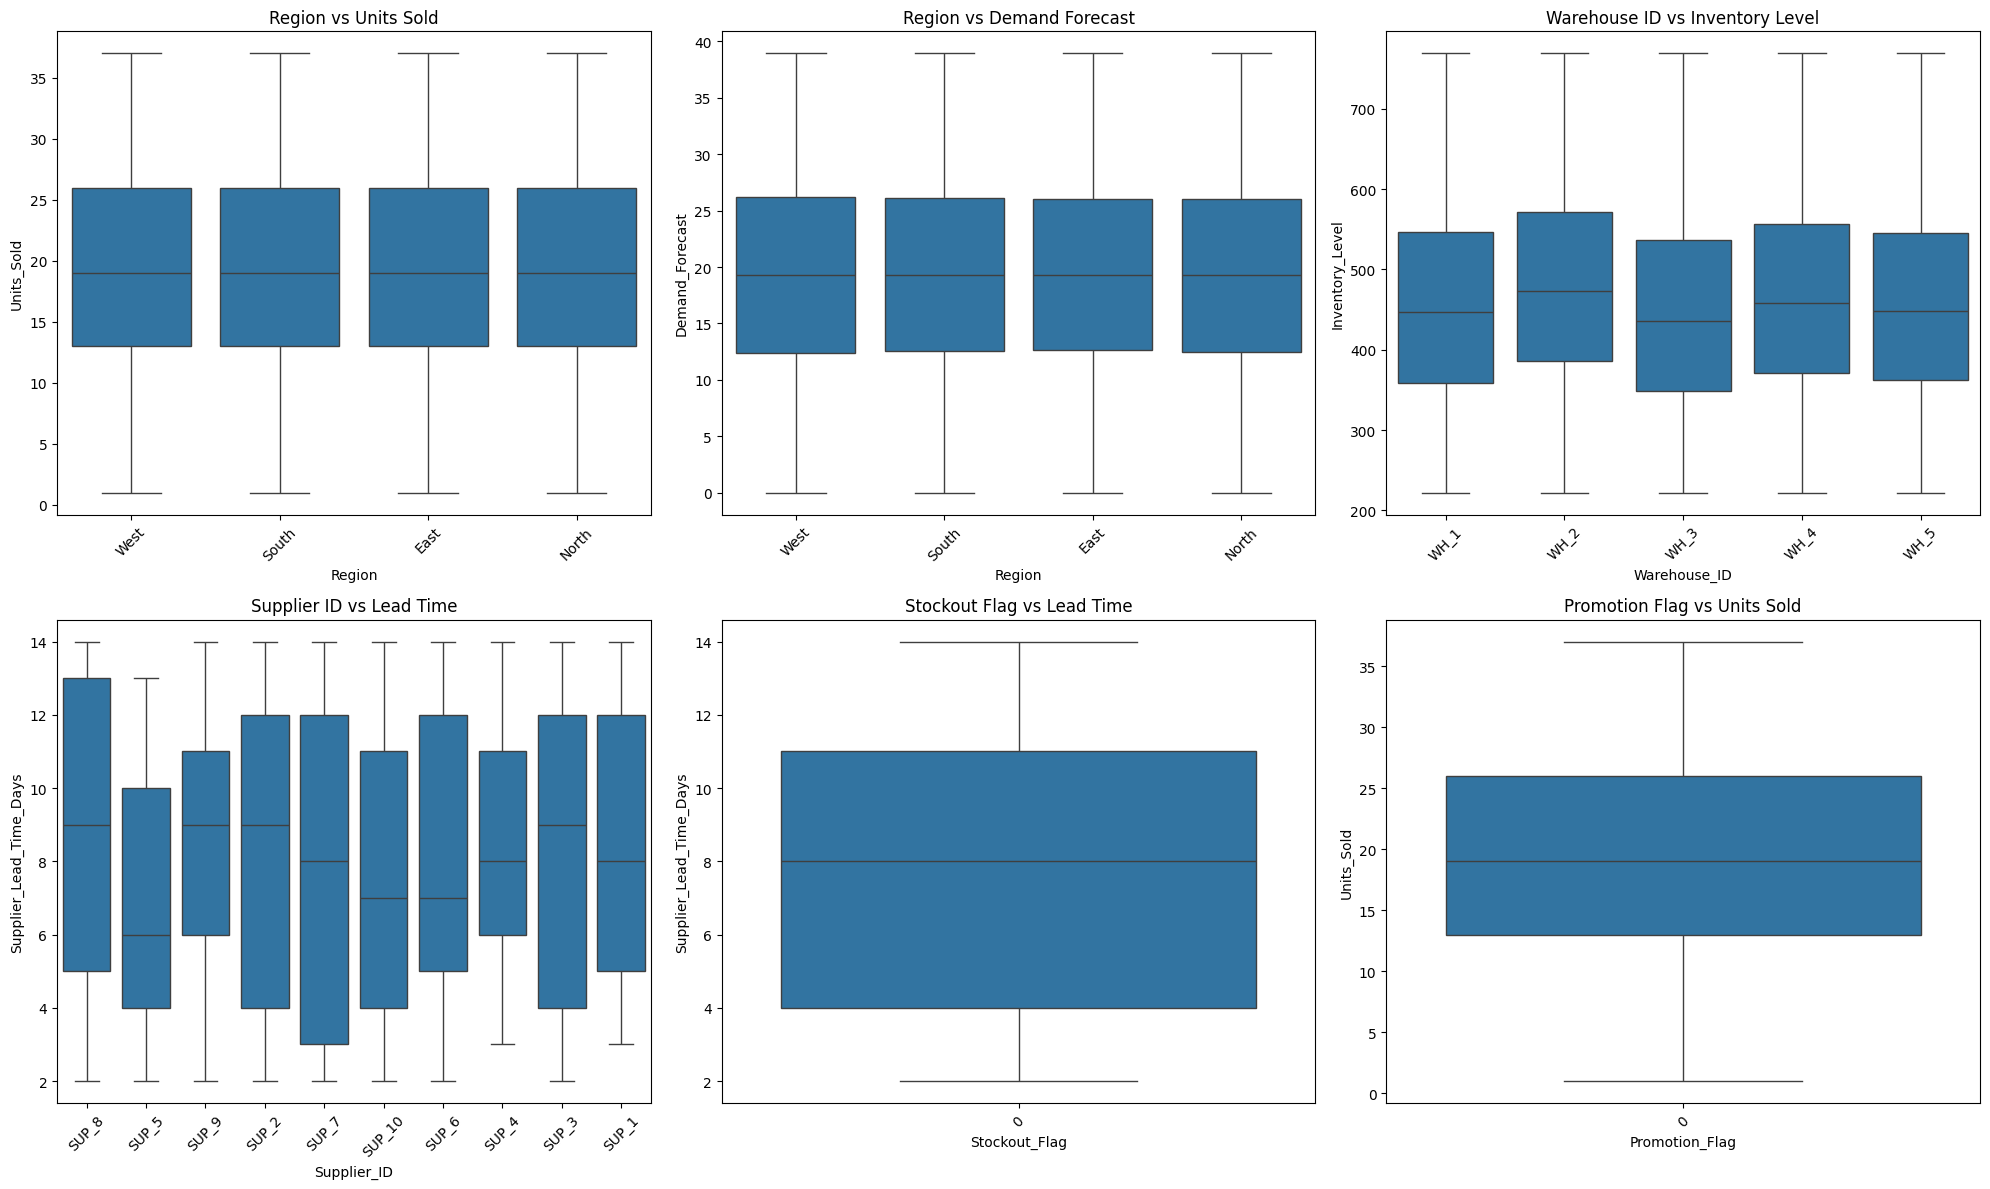

In [51]:
plt.figure(figsize=(20, 12))

# 1. Region vs Units Sold
plt.subplot(2, 3, 1)
sns.boxplot(x='Region', y='Units_Sold', data=df)
plt.title('Region vs Units Sold')
plt.xticks(rotation=45)

# 2. Region vs Demand Forecast
plt.subplot(2, 3, 2)
sns.boxplot(x='Region', y='Demand_Forecast', data=df)
plt.title('Region vs Demand Forecast')
plt.xticks(rotation=45)

# 3. Warehouse_ID vs Inventory Level
plt.subplot(2, 3, 3)
sns.boxplot(x='Warehouse_ID', y='Inventory_Level', data=df)
plt.title('Warehouse ID vs Inventory Level')
plt.xticks(rotation=45)

# 4. Supplier_ID vs Supplier Lead Time Days
plt.subplot(2, 3, 4)
sns.boxplot(x='Supplier_ID', y='Supplier_Lead_Time_Days', data=df)
plt.title('Supplier ID vs Lead Time')
plt.xticks(rotation=45)

# 5. Stockout_Flag vs Supplier Lead Time Days
plt.subplot(2, 3, 5)
sns.boxplot(x='Stockout_Flag', y='Supplier_Lead_Time_Days', data=df)
plt.title('Stockout Flag vs Lead Time')
plt.xticks(rotation=45)

# 6. Promotion_Flag vs Units Sold
plt.subplot(2, 3, 6)
sns.boxplot(x='Promotion_Flag', y='Units_Sold', data=df)
plt.title('Promotion Flag vs Units Sold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

For the regions we can see all the regions have the similar mean and similar quartiles as well while the lead time varies greatly for for supplier to supplier 

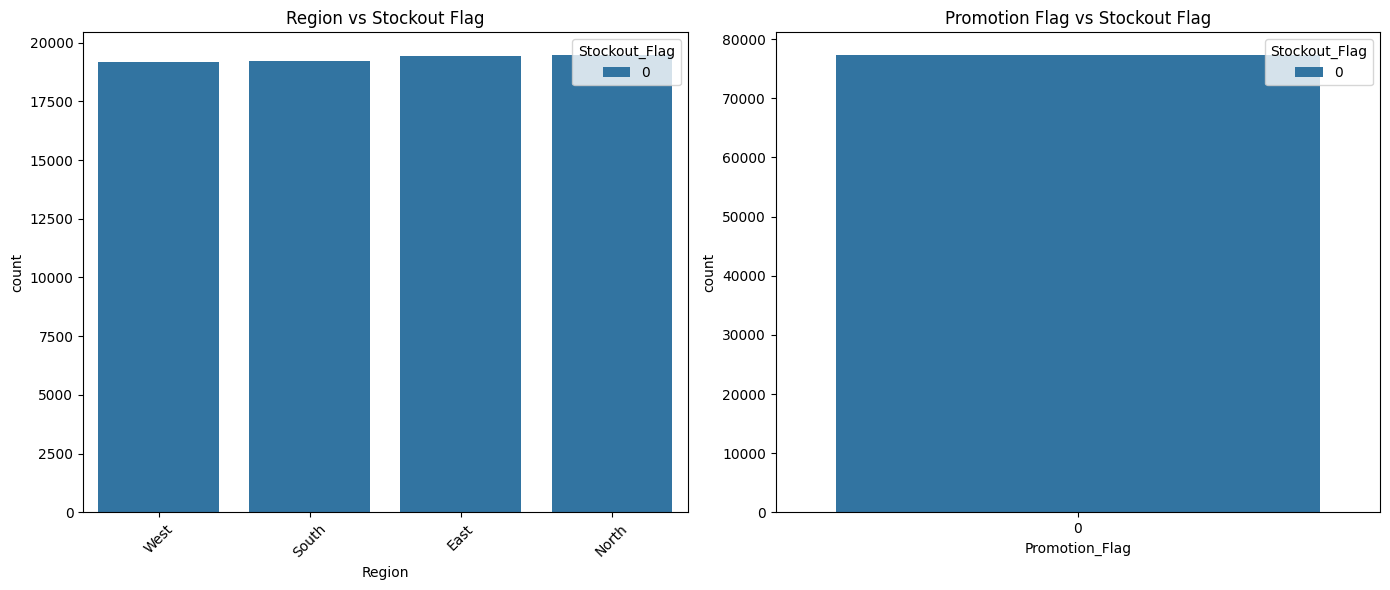

In [52]:
plt.figure(figsize=(14, 6))

# 1. Region vs Stockout Flag (Countplot)
plt.subplot(1, 2, 1)
sns.countplot(x='Region', hue='Stockout_Flag', data=df)
plt.title('Region vs Stockout Flag')
plt.xticks(rotation=45)

# 2. Promotion Flag vs Stockout Flag (Countplot)
plt.subplot(1, 2, 2)
sns.countplot(x='Promotion_Flag', hue='Stockout_Flag', data=df)
plt.title('Promotion Flag vs Stockout Flag')

plt.tight_layout()
plt.show()

The variables lack the insights for the analysis and there for doesnot provide any meaningful insight. 

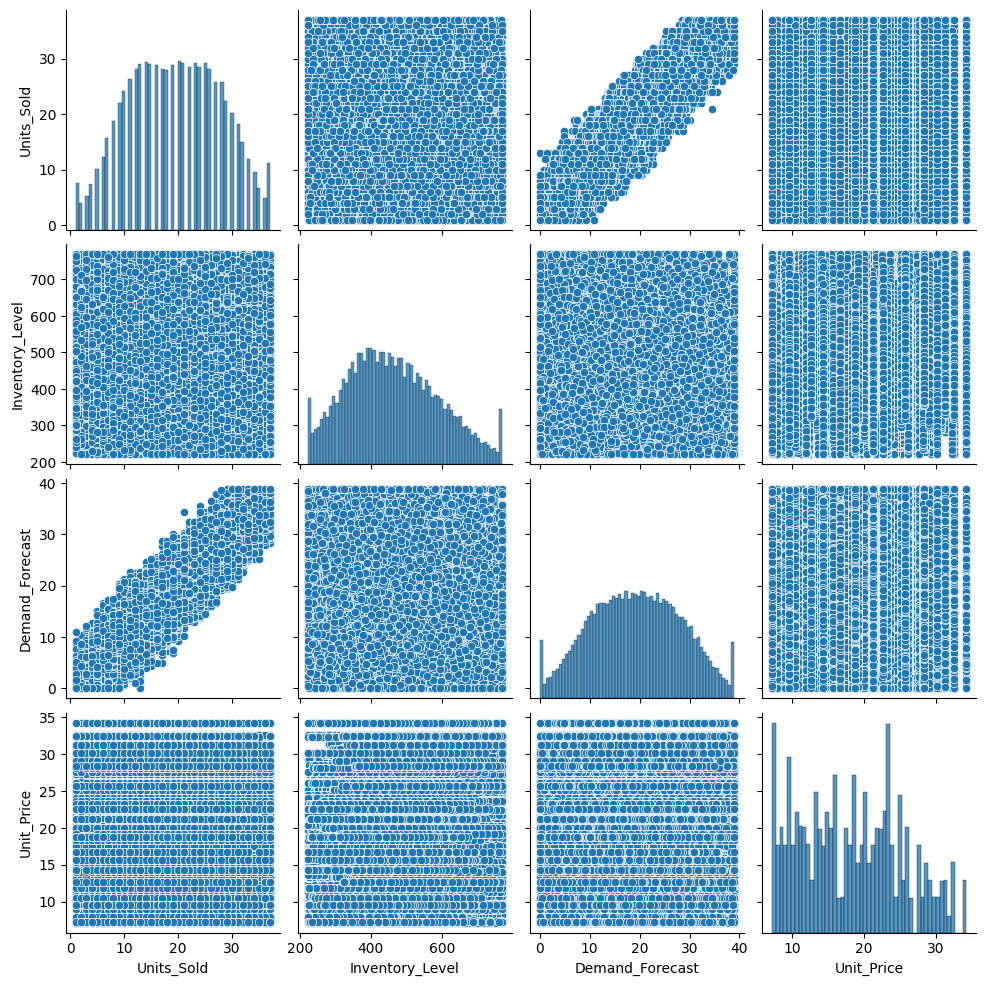

In [58]:
sns.pairplot(df[['Units_Sold','Inventory_Level','Demand_Forecast','Unit_Price']])
plt.show()